Import and get lens

In [1]:
#imports
import torch as th
import numpy as np
import matplotlib.pyplot as plt

In [9]:
from utils.load_dataset import load_dataset
dataset = 'mnist'
train, test, val = load_dataset(dataset, metrics_file='metrics_merged.csv', load_class_acc=True)

weights_train, outputs_train, configs_train = train
weights_test, outputs_test, configs_test = test
weights_val, outputs_val, configs_val = val

train_class_accuracies = outputs_train[:, -10:]
test_class_accuracies = outputs_test[:, -10:]
val_class_accuracies = outputs_val[:, -10:]

In [10]:
from lenses.regressor_lens import get_regressor_lens, mse_mae
regressor_lens = get_regressor_lens(weights_train, train_class_accuracies, weights_val, val_class_accuracies)

Epoch   1 ─ val MSE 0.015841 | val MAE 0.074191
Epoch   2 ─ val MSE 0.010872 | val MAE 0.057917
Epoch   3 ─ val MSE 0.009566 | val MAE 0.055599
Epoch   4 ─ val MSE 0.009917 | val MAE 0.058198
Epoch   5 ─ val MSE 0.008834 | val MAE 0.053507
Epoch   6 ─ val MSE 0.009511 | val MAE 0.053617
Epoch   7 ─ val MSE 0.008413 | val MAE 0.050124
Epoch   8 ─ val MSE 0.008987 | val MAE 0.052479
Epoch   9 ─ val MSE 0.008313 | val MAE 0.048866
Epoch  10 ─ val MSE 0.009353 | val MAE 0.051936
Epoch  11 ─ val MSE 0.009762 | val MAE 0.053719
Epoch  12 ─ val MSE 0.008374 | val MAE 0.050538
Epoch  13 ─ val MSE 0.008794 | val MAE 0.049787
Epoch  14 ─ val MSE 0.009868 | val MAE 0.058140
Epoch  15 ─ val MSE 0.008275 | val MAE 0.047432
Epoch  16 ─ val MSE 0.009110 | val MAE 0.050891
Epoch  17 ─ val MSE 0.008758 | val MAE 0.051825
Epoch  18 ─ val MSE 0.008706 | val MAE 0.049303
Epoch  19 ─ val MSE 0.009016 | val MAE 0.051205
Epoch  20 ─ val MSE 0.008074 | val MAE 0.047413
Epoch  21 ─ val MSE 0.009701 | val MAE 0

In [12]:
# test regressor on test set
loader = th.utils.data.DataLoader(
    th.utils.data.TensorDataset(th.tensor(weights_test, dtype=th.float32), th.tensor(test_class_accuracies, dtype=th.float32)),
    batch_size=1000, shuffle=False
)
mse, mae  = mse_mae(regressor_lens, loader)
print(f"Test set MSE: {mse:.4f}, MAE: {mae:.4f}")

Test set MSE: 0.0090, MAE: 0.0515


LGTM

The probe learned well, but it did not learn exceptionally well. Perhaps for proper backprop we need lower MSE. Let's proceed anyway.

# Backprop wrt to input weight
Let's see if we can backpropagate wrt the input weights

Model Index: 502


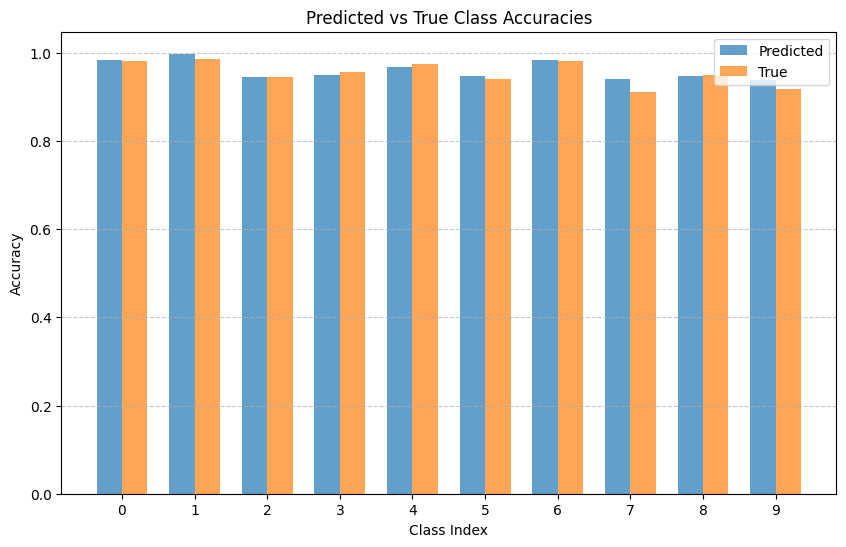

Training Params config.w_init            he_normal
config.activation             relu
config.learning_rate      0.007303
config.init_std           0.181863
config.l2reg              0.000006
config.train_fraction          0.1
config.dropout            0.241651
Name: /cns/vj-d/home/brain-ber/dnn_science/unterthiner/smallcnnzoo/mnist/11169528/3006/permanent_ckpt-86, dtype: object
True Overal CNN Test Accuracy 0.9549


In [54]:
# get a model from test set
MODEL_IDX = 502
print(f"Model Index: {MODEL_IDX}")
model_weights = th.tensor(weights_test[MODEL_IDX], dtype=th.float32)
pred = regressor_lens(model_weights.unsqueeze(0)).squeeze(0)


plt.figure(figsize=(10, 6))
bar_width = 0.35
indices = np.arange(len(pred.detach().numpy()))

plt.bar(indices, pred.detach().numpy(), bar_width, label='Predicted', alpha=0.7)
plt.bar(indices + bar_width, test_class_accuracies[MODEL_IDX], bar_width, label='True', alpha=0.7)

plt.xlabel('Class Index')
plt.ylabel('Accuracy')
plt.title('Predicted vs True Class Accuracies')
plt.xticks(indices + bar_width / 2, indices)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Training Params", configs_test.iloc[MODEL_IDX])
print("True Overal CNN Test Accuracy", outputs_test[MODEL_IDX][0])

In [83]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Bar(
    x=indices,
    y=model_weights.detach().numpy(),
    name=f'Model Weights of {MODEL_IDX}',
    marker=dict(opacity=0.7)
))

fig.update_layout(
    title='Barplot of Model Weights',
    xaxis_title='Weight Index',
    yaxis_title='Weight Value',
    xaxis=dict(range=[4000, 4100]),
    legend=dict(title='Legend'),
    bargap=0.2,
    template='plotly_white'
)

fig.show()

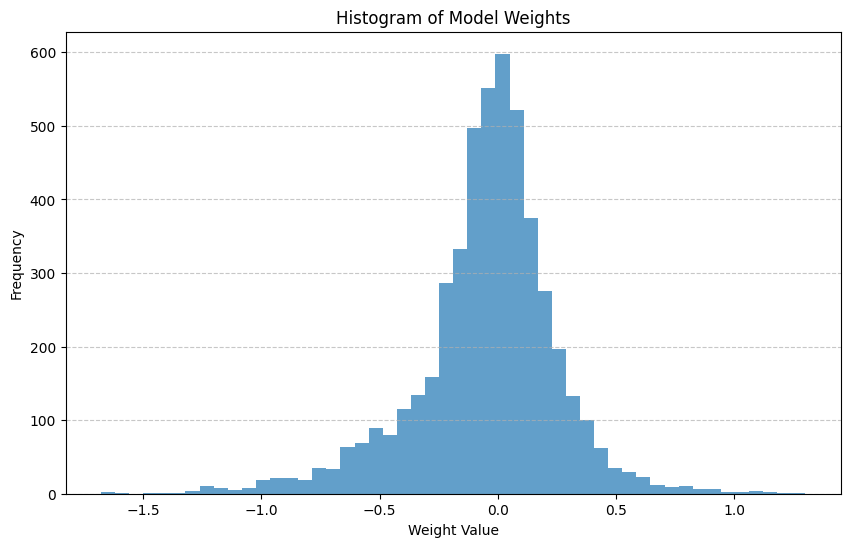

In [81]:
plt.figure(figsize=(10, 6))
plt.hist(model_weights.detach().numpy(), bins=50, alpha=0.7)
plt.xlabel('Weight Value')
plt.ylabel('Frequency')
plt.title('Histogram of Model Weights')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [23]:
from utils.reconstruct_network import reconstruct_network
from evaluate_per_class_accuracy import evaluate_classifier, load_testset_data

def test_network_accuracy(model_weights, activation):
    model = reconstruct_network(model_weights, activation)
    # we have to compile model before evaluating, func arguments are not used except metrics
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    x_test, y_test = load_testset_data(dataset)
    acc, class_acc = evaluate_classifier(model, x_test, y_test)

    return acc, class_acc


In [24]:
simple_loss = lambda pred, true, target: pred[target]
targeted_loss = lambda pred, true, target: pred[target] + ((true - pred) ** 2).mean()

We are going to try to decrease Class 5 accuracy.

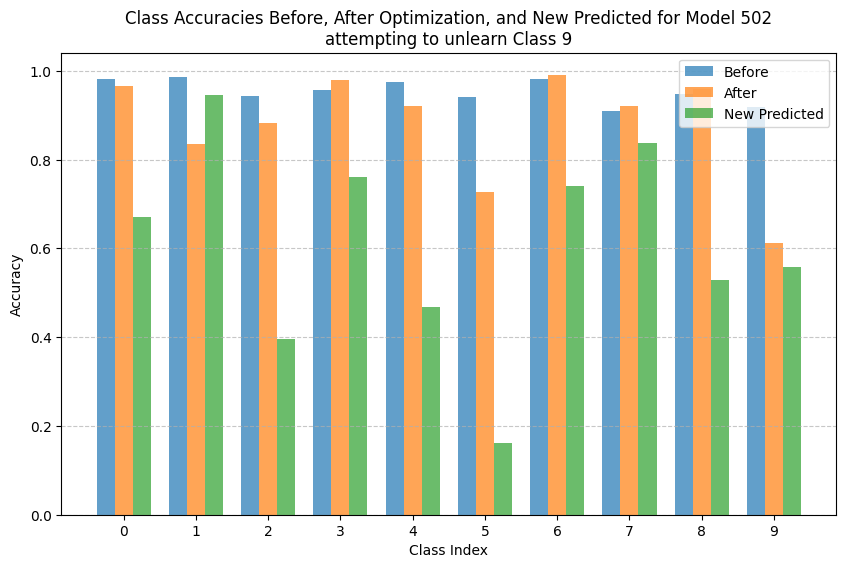

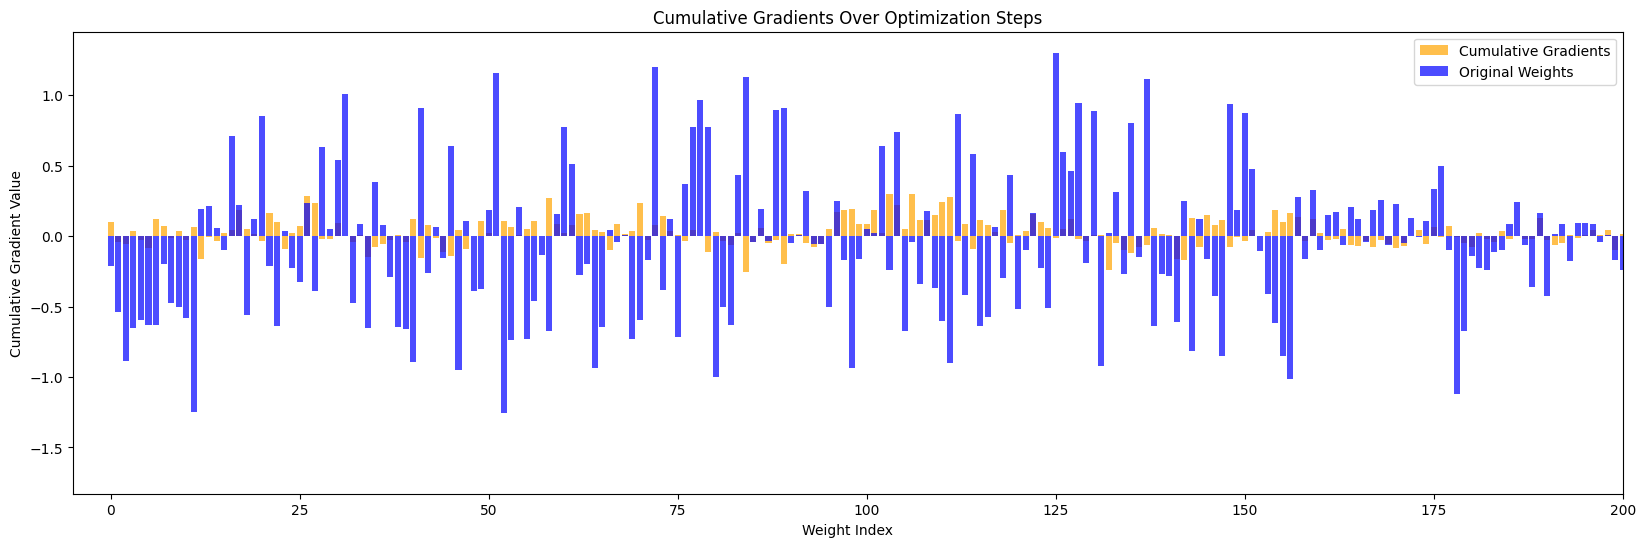

In [78]:
target_class = 9
STEPS = 210

# convert model weights to tensor, require grad
doctored_weights = th.tensor(weights_test[MODEL_IDX], dtype=th.float32, requires_grad=True)
cum_grads = th.zeros_like(doctored_weights)
# freeze regressor lens weights
regressor_lens.eval()  # set regressor lens to evaluation mode
for param in regressor_lens.parameters():
    param.requires_grad = False
for i in range(STEPS):
    # forward pass
    pred = regressor_lens(doctored_weights.unsqueeze(0)).squeeze(0)
    true = th.tensor(test_class_accuracies[MODEL_IDX], dtype=th.float32)
    # compute loss for target class
    loss = simple_loss(pred, true, target_class)  # we want to minimize the accuracy for target class
    # backward pass
    loss.backward()
    # get gradients
    gradients = doctored_weights.grad
    # take small gradient step
    step_size = 0.0035
    cum_grads += gradients.detach().numpy() * step_size
    doctored_weights.data -= step_size * gradients

class_acc_before = test_class_accuracies[MODEL_IDX]
acc_after, class_acc_after = test_network_accuracy(doctored_weights.detach().numpy(), configs_test.iloc[MODEL_IDX]['config.activation'])

plt.figure(figsize=(10, 6))
indices = np.arange(len(class_acc_before))

bar_width = 0.25

plt.bar(indices, class_acc_before, bar_width, label='Before', alpha=0.7)
plt.bar(indices + bar_width, class_acc_after, bar_width, label='After', alpha=0.7)
plt.bar(indices + 2 * bar_width, pred.detach().numpy(), bar_width, label='New Predicted', alpha=0.7)

plt.xlabel('Class Index')
plt.ylabel('Accuracy')
plt.title(f'Class Accuracies Before, After Optimization, and New Predicted for Model {MODEL_IDX}\nattempting to unlearn Class {target_class}')
plt.xticks(indices + bar_width, indices)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# plot cumulated gradients
plt.figure(figsize=(20, 6))
indices = np.arange(len(cum_grads.detach().numpy()))
plt.bar(indices, -cum_grads.detach().numpy(), alpha=0.7, color='orange', label='Cumulative Gradients')
# original weights
plt.bar(indices, weights_test[MODEL_IDX], alpha=0.7, color='blue', label='Original Weights')
plt.xlabel('Weight Index')
plt.ylabel('Cumulative Gradient Value')
plt.title('Cumulative Gradients Over Optimization Steps')
plt.xlim(-5,200)
plt.legend()

## L2Reg stuff

In [ ]:
# give dataframe integer index
configs_test.reset_index(inplace=True)
configs_test

,model_name,config.w_init,config.activation,config.learning_rate,config.init_std,config.l2reg,config.train_fraction,config.dropout
0,/cns/vj-d/home/brain-ber/dnn_science/unterthin...,TruncatedNormal,tanh,0.026508,0.012419,9.770899e-07,0.25,0.167976
1,/cns/vj-d/home/brain-ber/dnn_science/unterthin...,RandomNormal,relu,0.015154,0.013096,5.118623e-03,1.00,0.033163
2,/cns/vj-d/home/brain-ber/dnn_science/unterthin...,glorot_normal,tanh,0.028778,0.057326,2.589774e-08,0.50,0.663594
3,/cns/vj-d/home/brain-ber/dnn_science/unterthin...,TruncatedNormal,tanh,0.001090,0.062985,4.440091e-06,0.10,0.227308
4,/cns/vj-d/home/brain-ber/dnn_science/unterthin...,glorot_normal,relu,0.003334,0.033425,1.278729e-03,1.00,0.515106
...,...,...,...,...,...,...,...,...
14991,/cns/vj-d/home/brain-ber/dnn_science/unterthin...,he_normal,relu,0.014042,0.001812,2.440806e-07,0.50,0.640711
14992,/cns/vj-d/home/brain-ber/dnn_science/unterthin...,TruncatedNormal,tanh,0.024447,0.119930,4.104225e-07,0.25,0.316141
14993,/cns/vj-d/home/brain-ber/dnn_science/unterthin...,he_normal,relu,0.004835,0.001013,3.494506e-07,0.10,0.550408
14994,/cns/vj-d/home/brain-ber/dnn_science/unterthin...,orthogonal,relu,0.005436,0.007226,2.154771e-06,0.50,0.229165


In [ ]:
# get all config.l2reg <= 1e-7
low_l2reg_index = configs_test[configs_test['config.l2reg'] <= 1e-7].index
# get only indices > val_size
low_l2reg_index = low_l2reg_index[low_l2reg_index > val_size]

In [ ]:
# test low l2reg models
low_l2reg_weights = th.tensor(test_weights[low_l2reg_index - val_size], dtype=th.float32)
low_l2reg_class_accuracies = th.tensor(test_class_accuracies[low_l2reg_index - val_size], dtype=th.float32)
low_l2reg_loader = th.utils.data.DataLoader(
    th.utils.data.TensorDataset(low_l2reg_weights, low_l2reg_class_accuracies),
    batch_size=1000, shuffle=False
)
mse, mae = mse_mae(regressor_lens, low_l2reg_loader)
print(f"Low L2Reg Test set MSE: {mse:.4f}, MAE: {mae:.4f}")

Low L2Reg Test set MSE: 0.0082, MAE: 0.0511


In [ ]:
# repeat for high l2reg models
high_l2reg_index = configs_test[configs_test['config.l2reg'] > 1e-3].index
# get only indices > val_size
high_l2reg_index = high_l2reg_index[high_l2reg_index > val_size]
# test high l2reg models
high_l2reg_weights = th.tensor(test_weights[high_l2reg_index - val_size], dtype=th.float32)
high_l2reg_class_accuracies = th.tensor(test_class_accuracies[high_l2reg_index - val_size], dtype=th.float32)
high_l2reg_loader = th.utils.data.DataLoader(
    th.utils.data.TensorDataset(high_l2reg_weights, high_l2reg_class_accuracies),
    batch_size=1000, shuffle=False
)
mse, mae = mse_mae(regressor_lens, high_l2reg_loader)
print(f"High L2Reg Test set MSE: {mse:.4f}, MAE: {mae:.4f}")

High L2Reg Test set MSE: 0.0100, MAE: 0.0549


In [ ]:
len(high_l2reg_index)

855